# Research Question 1 (RQ1)

Can the search behaviour indicators differentiate between metaheuristics with that are exhibiting different behaviour? To test this, we use a Kolmogorov-Smirnov (KS) test. 

## Preparation
Steps before RQ1 can be evaluated.

In [ ]:
from scipy.stats import kstest
import pandas as pd
import numpy as np
import seaborn as sns
import itertools

sns.set_theme(style="ticks", palette="pastel")
sns.set(font='serif')
%matplotlib inline

In [1]:
tags = ["experiment","dimension","population_size","total_iterations","function","metaheuristic","control_parameters","run"]
diversity = ["DRoC Type A","DRoC Type B","ERT Diversity","Critical Diversity"]
fitness = ["FRoC Type A","FRoC Type B","ERT Fitness","Critical Fitness"]
separation = ["SRoC Type A","SRoC Type B","ERT Separation","Critical Separation"]
mobility = ["MRoC Type A","MRoC Type B","ERT Mobility","Critical Mobility"]
STN = ["ntotal*","nbest*","nshared*","best-strength*"]
IN = ["Mean ID","Mean GC","SNID"]
others = ["EXPLORE%","INFEASIBLE%"]

indicators = diversity + fitness + separation + mobility + STN + IN + others
columns = tags + indicators
data = pd.read_csv("results.csv", names=columns)

In [7]:
metaheuristics = list(np.unique(data['metaheuristic']))
metaheuristics

['GBestPSO',
 'GreedyPSO',
 'Random20PSO',
 'RandomPSO',
 'RingPSO',
 'VonNeumannPSO']

In [8]:
functions = list(np.unique(data['function']))
functions

['AttractiveSector',
 'Brown',
 'Discus',
 'Ellipsoidal',
 'Elliptic',
 'Exponential',
 'GeneralizedDropWave',
 'GeneralizedEggCrate',
 'GeneralizedPrice2',
 'Mishra1',
 'NeedleEye',
 'Pinter',
 'Qing',
 'Rosenbrock',
 'SchwafferN7',
 'Schwefel_1.2',
 'Step3Function',
 'Weierstrass']

In [9]:
#  Sets to use in string manipulation
metaheuristics_short = {
    'GBestPSO': "sPSO",
    'Random20PSO': "20PSO",
    'RingPSO': "rPSO",
    'VonNeumannPSO': "vnPSO",
    'GreedyPSO': "gPSO",
    'RandomPSO': 'iPSO'
}
function_pretty = {
    'AttractiveSector': "Attractive Sector",
    'Brown': "Brown",
    'Discus': "Discus",
    'Ellipsoidal': "Ellipsoidal",
    'Elliptic': "Elliptic",
    'Exponential': "Exponential",
    'GeneralizedDropWave': "Drop Wave",
    'GeneralizedEggCrate': "Egg Crate",
    'GeneralizedPrice2': "Price 2",
    'Mishra1': "Mishra 1",
    'NeedleEye': "Needle Eye",
    'Pinter': "Pinter",
    'Qing': "Qing",
    'Rosenbrock': "Rosenbrock",
    'SchwafferN7': "Schwaffer 7",
    'Schwefel_1.2': "Schwefel $1.2$",
    'Step3Function': "Step 3",
    'Weierstrass': "Weierstrass",
}

### Pairing Metaheuristics

The KS test used compares two underlying distributions against each other. We use this to test the underlying distribution of the results for one metaheuristic, against the underlying distribution of results for another metaheuristic. To do this, we create each possible pair of metaheuristics.

We also want to know how different each of these metaheuristics are to each other. Metaheuristics that differ in both update function and social topology are going to be more dissimilar than those that differ in only one of those.

In [10]:
paired_metaheuristics = list(itertools.combinations(metaheuristics, 2))
paired_metaheuristics_string = [metaheuristics_short[pair[0]] + " - " + metaheuristics_short[pair[1]] for pair in paired_metaheuristics]
paired_metaheuristics_string

['sPSO - gPSO',
 'sPSO - 20PSO',
 'sPSO - iPSO',
 'sPSO - rPSO',
 'sPSO - vnPSO',
 'gPSO - 20PSO',
 'gPSO - iPSO',
 'gPSO - rPSO',
 'gPSO - vnPSO',
 '20PSO - iPSO',
 '20PSO - rPSO',
 '20PSO - vnPSO',
 'iPSO - rPSO',
 'iPSO - vnPSO',
 'rPSO - vnPSO']

In [11]:
neighbourhood_difference = [
    'sPSO - 20PSO',
    'sPSO - rPSO',
    'sPSO - vnPSO',
    '20PSO - rPSO',
    '20PSO - vnPSO',
    'rPSO - vnPSO'
]
update_difference = [
    'sPSO - gPSO',
    'sPSO - iPSO',
    'gPSO - iPSO'
]
double_difference = [
    '20PSO - iPSO',
    'iPSO - rPSO',
    'iPSO - vnPSO',
    'gPSO - 20PSO',
    'gPSO - vnPSO',
    'gPSO - rPSO'
]

## Preliminary Data Investigation

Before performing statistical tests, we want an idea of what our data looks like. We want an idea of whether NaN's are something we should be worried about.


In [12]:
df = data[["function", "metaheuristic"] + indicators]
nan_sum = df.isna().sum()
nan_sum[nan_sum > 0]

MRoC Type A    1
MRoC Type B    1
dtype: int64

In [13]:
# given the low number in comparison to the size of the data, we will just drop these rows
df = df.dropna(inplace=False)

## Statistical Test: Kolmogorov–Smirnov

We will perform our statistical test for every pair of metaheuristics, for every indicator, for every function. We aggregate our results by counting R's (reject the null hypothesis) and F's (fail to reject the null hypothesis).

In [13]:
paired_columns = sum([[(pair, "stat"), (pair, "p-val")] for pair in paired_metaheuristics_string], [])
multi_columns = pd.MultiIndex.from_tuples([("indicator", ""), ("function", "")] + paired_columns, names=["stat", "p-val"])
full_results_df = pd.DataFrame(columns=multi_columns)
result_df = pd.DataFrame(columns=["indicator", "function"] + paired_metaheuristics_string)
for indicator in indicators:
    for function in functions:
        function_df = df[df["function"] == function]
        results = [indicator, function]
        full_results = [indicator, function]
        for alg1, alg2 in paired_metaheuristics:
            result = kstest(
                rvs=function_df[function_df['metaheuristic'] == alg1][indicator],
                cdf=function_df[function_df['metaheuristic'] == alg2][indicator],
            )
            full_results.append(result[0])
            full_results.append(result[1])
            # bonferroni correction with 18 test families (the benchmark functions)
            if float(result[1]) < (0.05 / 18):
                results.append("R")
            else:
                results.append("F")
        result_df.loc[len(result_df.index)] = results
        full_results_df.loc[len(full_results_df.index)] = full_results
result_df["function"] = result_df["function"].apply(lambda x: function_pretty[x])
full_results_df["function"] = full_results_df["function"].apply(lambda x: function_pretty[x])
result_df.set_index(keys=["indicator", "function"], inplace=True)
full_results_df.set_index(keys=["indicator", "function"], inplace=True)

/home/lauren/git/code_masters/behaviouralBenchmarking/.venv2/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:394: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  return hypotest_fun_in(*args, **kwds)
/home/lauren/git/code_masters/behaviouralBenchmarking/.venv2/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:394: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  return hypotest_fun_in(*args, **kwds)
/home/lauren/git/code_masters/behaviouralBenchmarking/.venv2/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:394: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  return hypotest_fun_in(*args, **kwds)
/home/lauren/git/code_masters/behaviouralBenchmarking/.venv2/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:394: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  return hypotest_fun_in(*args, **kw

We have two dataframes. One with the full results, which will be found in the supplementary material:

In [14]:
full_results_df.head(6)

stat                          sPSO - gPSO           sPSO - 20PSO            \
p-val                                stat     p-val         stat     p-val   
indicator   function                                                         
DRoC Type A Attractive Sector    0.633333  0.000006     0.200000  0.594071   
            Brown                0.566667  0.000087     0.200000  0.594071   
            Discus               0.400000  0.015643     0.666667  0.000001   
            Ellipsoidal          0.333333  0.070888     0.200000  0.594071   
            Elliptic             0.500000  0.000900     0.300000  0.135004   
            Exponential          0.533333  0.000293     0.166667  0.807963   

stat                          sPSO - iPSO               sPSO - rPSO            \
p-val                                stat         p-val        stat     p-val   
indicator   function                                                            
DRoC Type A Attractive Sector         1.0  1.691123e-17    0.533333  0.000293   
            Brown                     1.0  1.691123e-17    0.433333  0.006548   
            Discus                    1.0  1.691123e-17    0.666667  0.000001   
            Ellipsoidal               1.0  1.691123e-17    0.600000  0.000024   
            Elliptic                  1.0  1.691123e-17    0.433333  0.006548   
            Exponential               1.0  1.691123e-17    0.333333  0.070888   

stat                          sPSO - vnPSO            ... 20PSO - rPSO  \
p-val                                 stat     p-val  ...         stat   
indicator   function                                  ...                
DRoC Type A Attractive Sector     0.300000  0.135004  ...     0.400000   
            Brown                 0.233333  0.392945  ...     0.366667   
            Discus                0.633333  0.000006  ...     0.266667   
            Ellipsoidal           0.300000  0.135004  ...     0.800000   
            Elliptic              0.400000  0.015643  ...     0.600000   
            Exponential           0.233333  0.392945  ...     0.333333   

stat                                        20PSO - vnPSO            \
p-val                                 p-val          stat     p-val   
indicator   function                                                  
DRoC Type A Attractive Sector  1.564339e-02      0.200000  0.594071   
            Brown              3.458008e-02      0.200000  0.594071   
            Discus             2.390730e-01      0.166667  0.807963   
            Ellipsoidal        8.466416e-10      0.333333  0.070888   
            Elliptic           2.366488e-05      0.266667  0.239073   
            Exponential        7.088799e-02      0.200000  0.594071   

stat                          iPSO - rPSO               iPSO - vnPSO  \
p-val                                stat         p-val         stat   
indicator   function                                                   
DRoC Type A Attractive Sector         1.0  1.691123e-17          1.0   
            Brown                     1.0  1.691123e-17          1.0   
            Discus                    1.0  1.691123e-17          1.0   
            Ellipsoidal               1.0  1.691123e-17          1.0   
            Elliptic                  1.0  1.691123e-17          1.0   
            Exponential               1.0  1.691123e-17          1.0   

stat                                        rPSO - vnPSO            
p-val                                 p-val         stat     p-val  
indicator   function                                                
DRoC Type A Attractive Sector  1.691123e-17     0.300000  0.135004  
            Brown              1.691123e-17     0.200000  0.594071  
            Discus             1.691123e-17     0.166667  0.807963  
            Ellipsoidal        1.691123e-17     0.500000  0.000900  
            Elliptic           1.691123e-17     0.366667  0.034580  
            Exponential        1.691123e-17     0.233333  0

and another where we only declare whether the KS rejected the null hypothesis, or not.

In [15]:
result_df.head(6)

sPSO - gPSO sPSO - 20PSO sPSO - iPSO  \
indicator   function                                                 
DRoC Type A Attractive Sector           R            F           R   
            Brown                       R            F           R   
            Discus                      F            R           R   
            Ellipsoidal                 F            F           R   
            Elliptic                    R            F           R   
            Exponential                 R            F           R   

                              sPSO - rPSO sPSO - vnPSO gPSO - 20PSO  \
indicator   function                                                  
DRoC Type A Attractive Sector           R            F            R   
            Brown                       F            F            R   
            Discus                      R            R            F   
            Ellipsoidal                 R            F            F   
            Elliptic                    F            F            R   
            Exponential                 F            F            R   

                              gPSO - iPSO gPSO - rPSO gPSO - vnPSO  \
indicator   function                                                 
DRoC Type A Attractive Sector           R           R            R   
            Brown                       R           R            R   
            Discus                      R           F            F   
            Ellipsoidal                 R           R            R   
            Elliptic                    R           R            R   
            Exponential                 R           R            R   

                              20PSO - iPSO 20PSO - rPSO 20PSO - vnPSO  \
indicator   function                                                    
DRoC Type A Attractive Sector            R            F             F   
            Brown                        R            F             F   
            Discus                       R            F             F   
            Ellipsoidal                  R            R             F   
            Elliptic                     R            R             F   
            Exponential                  R            F             F   

                              iPSO - rPSO iPSO - vnPSO rPSO - vnPSO  
indicator   function                                                 
DRoC Type A Attractive Sector           R            R            F  
            Brown                       R            R            F  
            Discus                      R            R            F  
            Ellipsoidal                 R            R            R  
            Elliptic                    R            R            F  
            Exponential                 R            R            F

## Paper Visualisation

The results need to be further summarised to fit in the paper. 

We will calculate the ratio of "Fail to reject the null hypothesis" outcomes to "Reject the null hypothesis" outcomes for each indicator and pair of metaheuristics. This tells us how frequently the indicator does not pick up on the search behaviour differences between two metaheuristics.

In [16]:
small_table = pd.DataFrame(columns=[""] + paired_metaheuristics_string)
for indicator in indicators:
    failure_rate = [indicator]
    for metaheuristic in paired_metaheuristics_string:
        counts = result_df.loc[indicator][metaheuristic].value_counts()
        if "F" in counts:
            failure_rate.append(round(counts["F"] / 18 * 100, 1))
        else:
            failure_rate.append(0)
    small_table.loc[len(small_table.index)] = failure_rate
small_table.set_index(keys=[""], inplace=True)
small_table_t = small_table.transpose()
small_table_t.head()

,DRoC Type A,DRoC Type B,ERT Diversity,Critical Diversity,FRoC Type A,FRoC Type B,ERT Fitness,Critical Fitness,SRoC Type A,SRoC Type B,...,Critical Mobility,ntotal*,nbest*,nshared*,best-strength*,Mean ID,Mean GC,SNID,EXPLORE%,INFEASIBLE%
sPSO - gPSO,38.9,38.9,33.3,33.3,66.7,72.2,66.7,77.8,50.0,88.9,...,50.0,66.7,61.1,72.2,27.8,22.2,22.2,5.6,22.2,72.2
sPSO - 20PSO,88.9,61.1,16.7,38.9,77.8,50.0,77.8,50.0,55.6,55.6,...,38.9,0.0,50.0,16.7,33.3,38.9,16.7,38.9,0.0,0.0
sPSO - iPSO,0.0,50.0,0.0,0.0,50.0,22.2,50.0,0.0,38.9,33.3,...,0.0,0.0,27.8,0.0,27.8,27.8,27.8,16.7,0.0,0.0
sPSO - rPSO,38.9,16.7,11.1,22.2,33.3,11.1,38.9,11.1,27.8,22.2,...,27.8,0.0,55.6,16.7,27.8,0.0,0.0,27.8,0.0,0.0
sPSO - vnPSO,83.3,38.9,11.1,27.8,50.0,33.3,50.0,33.3,33.3,27.8,...,22.2,0.0,50.0,5.6,33.3,0.0,0.0,38.9,0.0,0.0


To make the table nice and pretty, we will colour the results in according to the type of difference between the metaheuristics in the related metaheuristic pair.

/tmp/ipykernel_314470/62479246.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


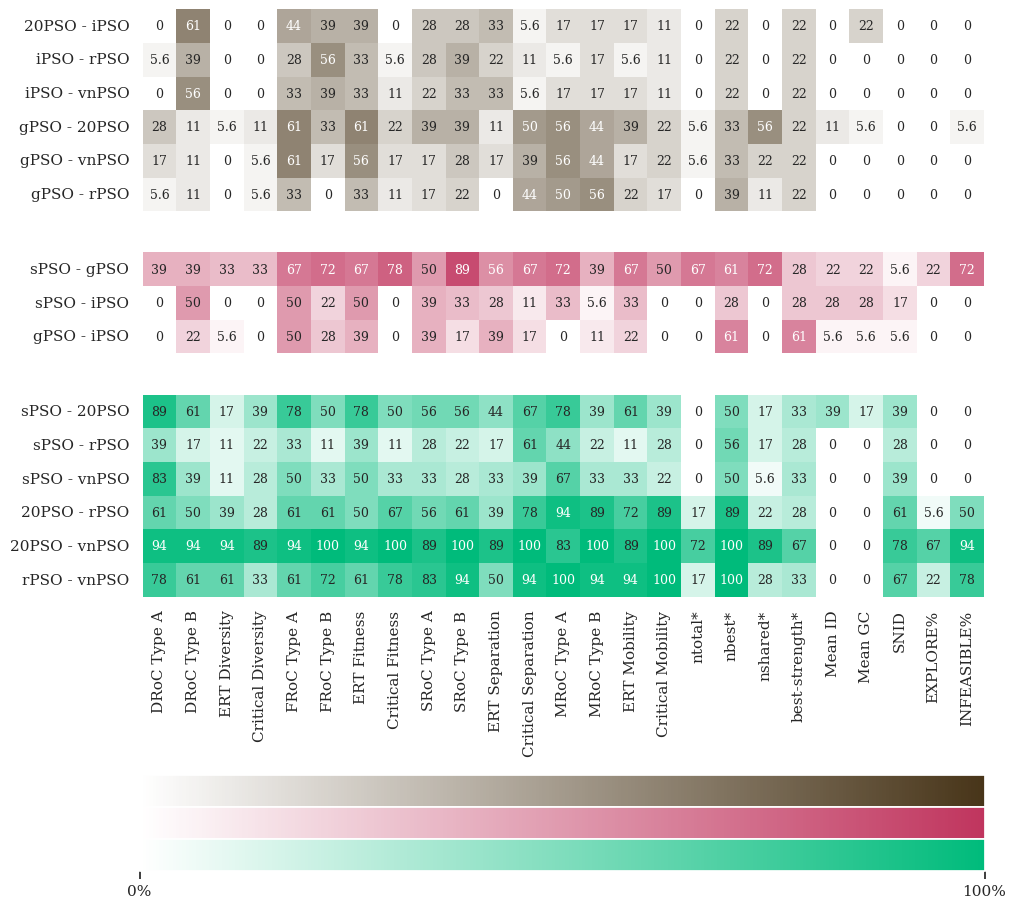

In [50]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
sns.set_theme(style="ticks", palette="pastel")
sns.set(font='serif')
%matplotlib inline

neighbourhood_difference_data = small_table[neighbourhood_difference]
update_difference_data = small_table[update_difference]
double_difference_data = small_table[double_difference]

def format_function(x):
    if float(x) == 100:
        return "100"
    else:
        return f"{float(x):.2g}"

# Define color maps from white to target color
cmap1 = mcolors.LinearSegmentedColormap.from_list("brown_map", ["white", "#483519"])
cmap2 = mcolors.LinearSegmentedColormap.from_list("pink_map", ["white", "#C0355E"])
cmap3 = mcolors.LinearSegmentedColormap.from_list("teal_map", ["white", "#00BB7B"])
fs = 9

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharey=False, sharex=True)

sns.heatmap(double_difference_data.T, cmap=cmap1, cbar=False, yticklabels=double_difference, xticklabels=False, square=True, annot=np.vectorize(format_function)(double_difference_data.T), fmt='', annot_kws={"fontsize":fs}, ax=axes[0], vmin=0, vmax=100)
sns.heatmap(update_difference_data.T, ax=axes[1], cmap=cmap2, cbar=False, yticklabels=update_difference, xticklabels=False, square=True, annot=np.vectorize(format_function)(update_difference_data.T), annot_kws={"fontsize":fs}, fmt='', vmin=0, vmax=100)
sns.heatmap(neighbourhood_difference_data.T, ax=axes[2], cmap=cmap3, cbar=False, yticklabels=neighbourhood_difference, xticklabels=small_table.index, square=True, annot=np.vectorize(format_function)(neighbourhood_difference_data.T), annot_kws={"fontsize":fs}, fmt='', vmin=0, vmax=100)

# three colour bars at the bottom
cbar_width = 0.845
cbar_height = 0.04
cbar_top = -0.11  # vertical offset from the bottom subplot
cbar_left = 0.5 * (1 - cbar_width) + 0.06
norm = mcolors.Normalize(vmin=0, vmax=100)

cb1 = fig.add_axes([cbar_left, cbar_top + 2*cbar_height, cbar_width, cbar_height])
cb2 = fig.add_axes([cbar_left, cbar_top + 1*cbar_height, cbar_width, cbar_height])
cb3 = fig.add_axes([cbar_left, cbar_top + 0*cbar_height, cbar_width, cbar_height])

plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap1), cax=cb1, orientation='horizontal')
plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap2), cax=cb2, orientation='horizontal')
plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap3), cax=cb3, orientation='horizontal')

cb1.set_xticks([])
cb2.set_xticks([])
cb3.set_xticks([0, 100])
cb3.set_xticklabels(['0%', '100%'])

plt.tight_layout()
plt.savefig(f"../../plots/KS_test_results.pdf", bbox_inches='tight', dpi=600)
plt.show()


And finally for the supplementary material, we are going to save the tables to files.

In [50]:
full_results_df.to_csv("RQ1_KS_results.csv", header=True, index=True)